## Quick primer to Principal Component Analysis

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris


def standardise(data: np.ndarray) -> np.ndarray:
    return StandardScaler().fit_transform(data)


def run_pca(data: np.ndarray, n_components: int = None) -> tuple[PCA, np.ndarray]:
    pca = PCA(n_components=n_components)
    transformed = pca.fit_transform(data)
    return pca, transformed


def plot_correlation(x: np.ndarray, y: np.ndarray, xlabel: str, ylabel: str):
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.scatter(x, y, s=20, alpha=0.6)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(f"Correlation  (r = {np.corrcoef(x, y)[0,1]:.2f})")
    plt.tight_layout()
    plt.show()


def plot_principal_components(data: np.ndarray, pca: PCA):
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(data[:, 0], data[:, 1], s=20, alpha=0.5)
    for i, (component, color) in enumerate(zip(pca.components_, ["tab:red", "tab:orange"])):
        scale = pca.explained_variance_[i] ** 0.5
        ax.annotate("", xy=scale * component, xytext=-scale * component,
                    arrowprops=dict(arrowstyle="<->", color=color, lw=2))
        ax.text(*(scale * component + 0.05), f"PC{i+1} ({pca.explained_variance_ratio_[i]*100:.0f}%)",
                color=color, fontsize=9)
    ax.set_aspect("equal")
    ax.set_title("Principal Component Axes")
    plt.tight_layout()
    plt.show()


def plot_variance_explained(pca: PCA):
    pcs = np.arange(1, len(pca.explained_variance_ratio_) + 1)
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.bar(pcs, pca.explained_variance_ratio_ * 100, alpha=0.7)
    ax.set_xlabel("Principal Component")
    ax.set_ylabel("Variance Explained (%)")
    ax.set_title("Variance Explained per Component")
    ax.set_xticks(pcs)
    plt.tight_layout()
    plt.show()


def plot_cumulative_variance(pca: PCA):
    cumvar = np.cumsum(pca.explained_variance_ratio_) * 100
    pcs = np.arange(1, len(cumvar) + 1)
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.plot(pcs, cumvar, "o-")
    ax.axhline(95, color="grey", ls="--", lw=1, label="95%")
    ax.set_xlabel("Principal Component")
    ax.set_ylabel("Cumulative Variance Explained (%)")
    ax.set_title("Cumulative Variance Explained")
    ax.set_xticks(pcs)
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_projection(transformed: np.ndarray, pca: PCA, labels: np.ndarray = None, label_names: list = None):
    fig, ax = plt.subplots(figsize=(5, 4))
    if labels is not None:
        for i, name in enumerate(label_names):
            mask = labels == i
            ax.scatter(transformed[mask, 0], transformed[mask, 1], s=25, alpha=0.7, label=name)
        ax.legend()
    else:
        ax.scatter(transformed[:, 0], transformed[:, 1], s=25, alpha=0.7)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
    ax.set_title("PCA Projection")
    plt.tight_layout()
    plt.show()

def plot_scaler_importance():
    rng = np.random.default_rng(42)
    n = 200

    body_size = rng.standard_normal(n)
    height_mm = 1700 + 80 * body_size + rng.normal(0, 40, n)
    weight_kg  =  70 +  8 * body_size + rng.normal(0,  4, n)

    raw    = np.column_stack([height_mm, weight_kg])
    scaled = StandardScaler().fit_transform(raw)

    pca_raw    = PCA(n_components=2).fit(raw)
    pca_scaled = PCA(n_components=2).fit(scaled)

    # Wider first subplot via gridspec
    fig, axes = plt.subplots(1, 3, figsize=(17, 4),
                             gridspec_kw={"width_ratios": [2.5, 1.5, 1.5]})

    # ── 1. Raw scatter ───────────────────────────────────────────────────────
    ax = axes[0]
    ax.scatter(raw[:, 0], raw[:, 1], s=20, alpha=0.5, color="grey")
    for i, (comp, var, color) in enumerate(
        zip(pca_raw.components_, pca_raw.explained_variance_, ["tomato", "steelblue"])
    ):
        scale = var ** 0.5
        ax.annotate("", xy=pca_raw.mean_ + scale * comp,
                        xytext=pca_raw.mean_ - scale * comp,
                    arrowprops=dict(arrowstyle="<->", color=color, lw=2.5))
        ax.text(*(pca_raw.mean_ + scale * comp + [1, 0.3]),
                f"PC{i+1} ({pca_raw.explained_variance_ratio_[i]*100:.0f}%)",
                color=color, fontsize=9)
    ax.set_xlabel("Height (mm)")
    ax.set_ylabel("Weight (kg)")
    ax.set_title("Raw data\nPC1 is almost horizontal — driven purely by mm scale, not structure", fontsize=9)

    # ── 2. Scaled scatter ────────────────────────────────────────────────────
    ax = axes[1]
    ax.scatter(scaled[:, 0], scaled[:, 1], s=20, alpha=0.5, color="grey")
    origin = np.zeros(2)
    for i, (comp, var, color) in enumerate(
        zip(pca_scaled.components_, pca_scaled.explained_variance_, ["tomato", "steelblue"])
    ):
        scale = var ** 0.5
        ax.annotate("", xy=origin + scale * comp,
                        xytext=origin - scale * comp,
                    arrowprops=dict(arrowstyle="<->", color=color, lw=2.5))
        ax.text(*(origin + scale * comp + 0.05),
                f"PC{i+1} ({pca_scaled.explained_variance_ratio_[i]*100:.0f}%)",
                color=color, fontsize=9)
    ax.set_xlabel("Height (standardised)")
    ax.set_ylabel("Weight (standardised)")
    ax.set_title("Scaled data\nPC1 rotates to capture the real\ncorrelation between height & weight", fontsize=9)
    ax.set_aspect("equal")

    # ── 3. Bar chart ─────────────────────────────────────────────────────────
    ax = axes[2]
    x = np.arange(2)
    w = 0.35
    bars_r = ax.bar(x - w/2, pca_raw.explained_variance_ratio_    * 100, w, label="Raw",    color="tomato",    alpha=0.8)
    bars_s = ax.bar(x + w/2, pca_scaled.explained_variance_ratio_ * 100, w, label="Scaled", color="steelblue", alpha=0.8)
    for bar in [*bars_r, *bars_s]:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 1, f"{h:.0f}%",
                ha="center", va="bottom", fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(["PC1", "PC2"])
    ax.set_ylabel("Variance explained (%)")
    ax.set_title("Raw PC1 absorbs almost everything\n(scale artifact) vs scaled which\nshows a genuine 2-component structure", fontsize=9)
    ax.legend()
    ax.set_ylim(0, 110)

    fig.suptitle("Why StandardScaler matters for PCA", fontsize=12, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

In [ ]:

rng = np.random.default_rng(42)
x = rng.normal(size=200)
y = 0.85 * x + rng.normal(scale=0.4, size=200)
plot_correlation(x, y, "Dimension 1", "Dimension 2")

In [ ]:
toy_data = np.column_stack([x, y])
toy_scaled = standardise(toy_data)
toy_pca, toy_transformed = run_pca(toy_scaled)
plot_principal_components(toy_scaled, toy_pca)

In [ ]:
plot_scaler_importance()

In [ ]:
iris = load_iris()
iris_scaled = standardise(iris.data)
iris_scaled.shape ## num samples, num dimensions

In [ ]:
iris_pca_full, _ = run_pca(iris_scaled)
plot_variance_explained(iris_pca_full)


In [ ]:
plot_cumulative_variance(iris_pca_full)

In [ ]:

iris_pca, iris_transformed = run_pca(iris_scaled, n_components=2)
plot_projection(iris_transformed, iris_pca, iris.target, list(iris.target_names))

## Applying PCA to EEG Resting-State Features (`preprocess_v3.csv`)

198 subjects, 91 spectral features spanning 7 cortical regions (frontal, posterior, central, left temporal, right temporal, occipital, prefrontal). Each region contributes 13 features: absolute/relative power in delta, theta, alpha, beta, gamma bands, theta/beta ratio, peak alpha frequency, and spectral entropy.

In [8]:
import pandas as pd

# Load and inspect
eeg_df = pd.read_csv("preprocess_v3.csv")
print(f"Shape: {eeg_df.shape}  ({eeg_df.shape[0]} subjects, {eeg_df.shape[1]-1} features)")

# Drop non-numeric subject ID column
feature_cols = [c for c in eeg_df.columns if c != "subject"]
X_eeg = eeg_df[feature_cols].values

# Standardise
X_eeg_scaled = standardise(X_eeg)
print(f"Feature matrix after standardisation: {X_eeg_scaled.shape}")
eeg_df[feature_cols].describe().round(3)

Shape: (198, 92)  (198 subjects, 91 features)
Feature matrix after standardisation: (198, 91)


,frontal_abs_delta,frontal_rel_delta,frontal_abs_theta,frontal_rel_theta,frontal_abs_alpha,frontal_rel_alpha,frontal_abs_beta,frontal_rel_beta,frontal_abs_gamma,frontal_rel_gamma,...,prefrontal_rel_theta,prefrontal_abs_alpha,prefrontal_rel_alpha,prefrontal_abs_beta,prefrontal_rel_beta,prefrontal_abs_gamma,prefrontal_rel_gamma,prefrontal_theta_beta_ratio,prefrontal_peak_alpha_freq,prefrontal_spectral_entropy
count,198.0,198.000,198.0,198.000,198.0,198.000,198.0,198.000,198.0,198.000,...,198.000,198.0,198.000,198.0,198.000,198.0,198.000,198.000,198.000,198.000
mean,0.0,0.429,0.0,0.132,0.0,0.235,0.0,0.121,0.0,0.027,...,0.111,0.0,0.172,0.0,0.104,0.0,0.030,1.324,9.929,0.659
std,0.0,0.153,0.0,0.055,0.0,0.147,0.0,0.063,0.0,0.027,...,0.043,0.0,0.120,0.0,0.057,0.0,0.028,0.746,1.251,0.100
min,0.0,0.113,0.0,0.038,0.0,0.019,0.0,0.011,0.0,0.003,...,0.039,0.0,0.014,0.0,0.016,0.0,0.005,0.094,8.000,0.380
25%,0.0,0.327,0.0,0.094,0.0,0.118,0.0,0.077,0.0,0.013,...,0.080,0.0,0.081,0.0,0.065,0.0,0.015,0.824,9.000,0.591
50%,0.0,0.431,0.0,0.126,0.0,0.198,0.0,0.109,0.0,0.020,...,0.104,0.0,0.140,0.0,0.097,0.0,0.023,1.120,10.000,0.669
75%,0.0,0.518,0.0,0.159,0.0,0.337,0.0,0.154,0.0,0.030,...,0.134,0.0,0.227,0.0,0.128,0.0,0.033,1.665,11.000,0.732
max,0.0,0.850,0.0,0.467,0.0,0.616,0.0,0.440,0.0,0.237,...,0.317,0.0,0.560,0.0,0.422,0.0,0.240,4.519,12.500,0.931


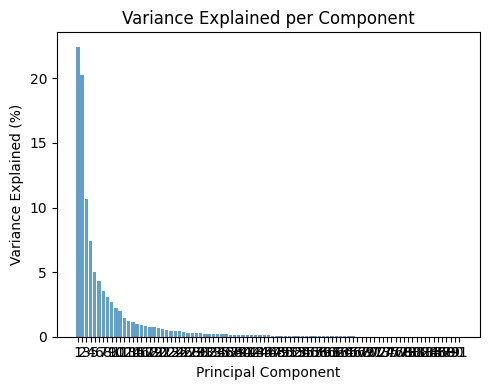

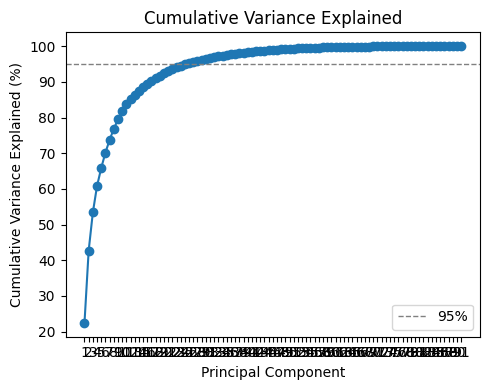

In [9]:
# Full PCA to inspect the variance structure
eeg_pca_full, _ = run_pca(X_eeg_scaled)
plot_variance_explained(eeg_pca_full)
plot_cumulative_variance(eeg_pca_full)

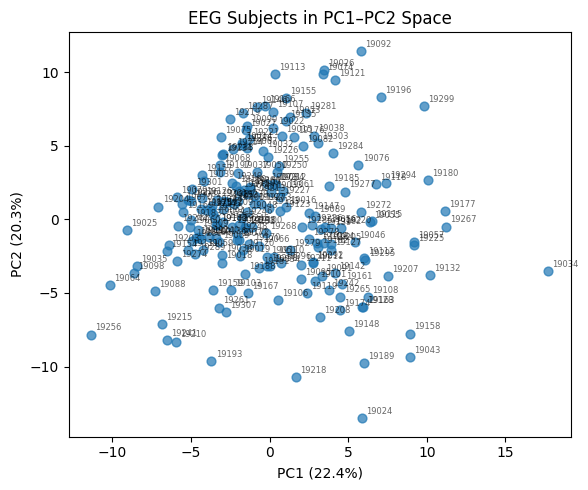

In [10]:
# Project to 2D and visualise subjects in PC space
eeg_pca_2d, eeg_transformed_2d = run_pca(X_eeg_scaled, n_components=2)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(eeg_transformed_2d[:, 0], eeg_transformed_2d[:, 1], s=40, alpha=0.7)

# Annotate each point with the subject ID
for i, subj in enumerate(eeg_df["subject"].values):
    ax.annotate(str(subj), (eeg_transformed_2d[i, 0], eeg_transformed_2d[i, 1]),
                fontsize=6, alpha=0.6, xytext=(3, 3), textcoords="offset points")

ax.set_xlabel(f"PC1 ({eeg_pca_2d.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({eeg_pca_2d.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("EEG Subjects in PC1–PC2 Space")
plt.tight_layout()
plt.show()

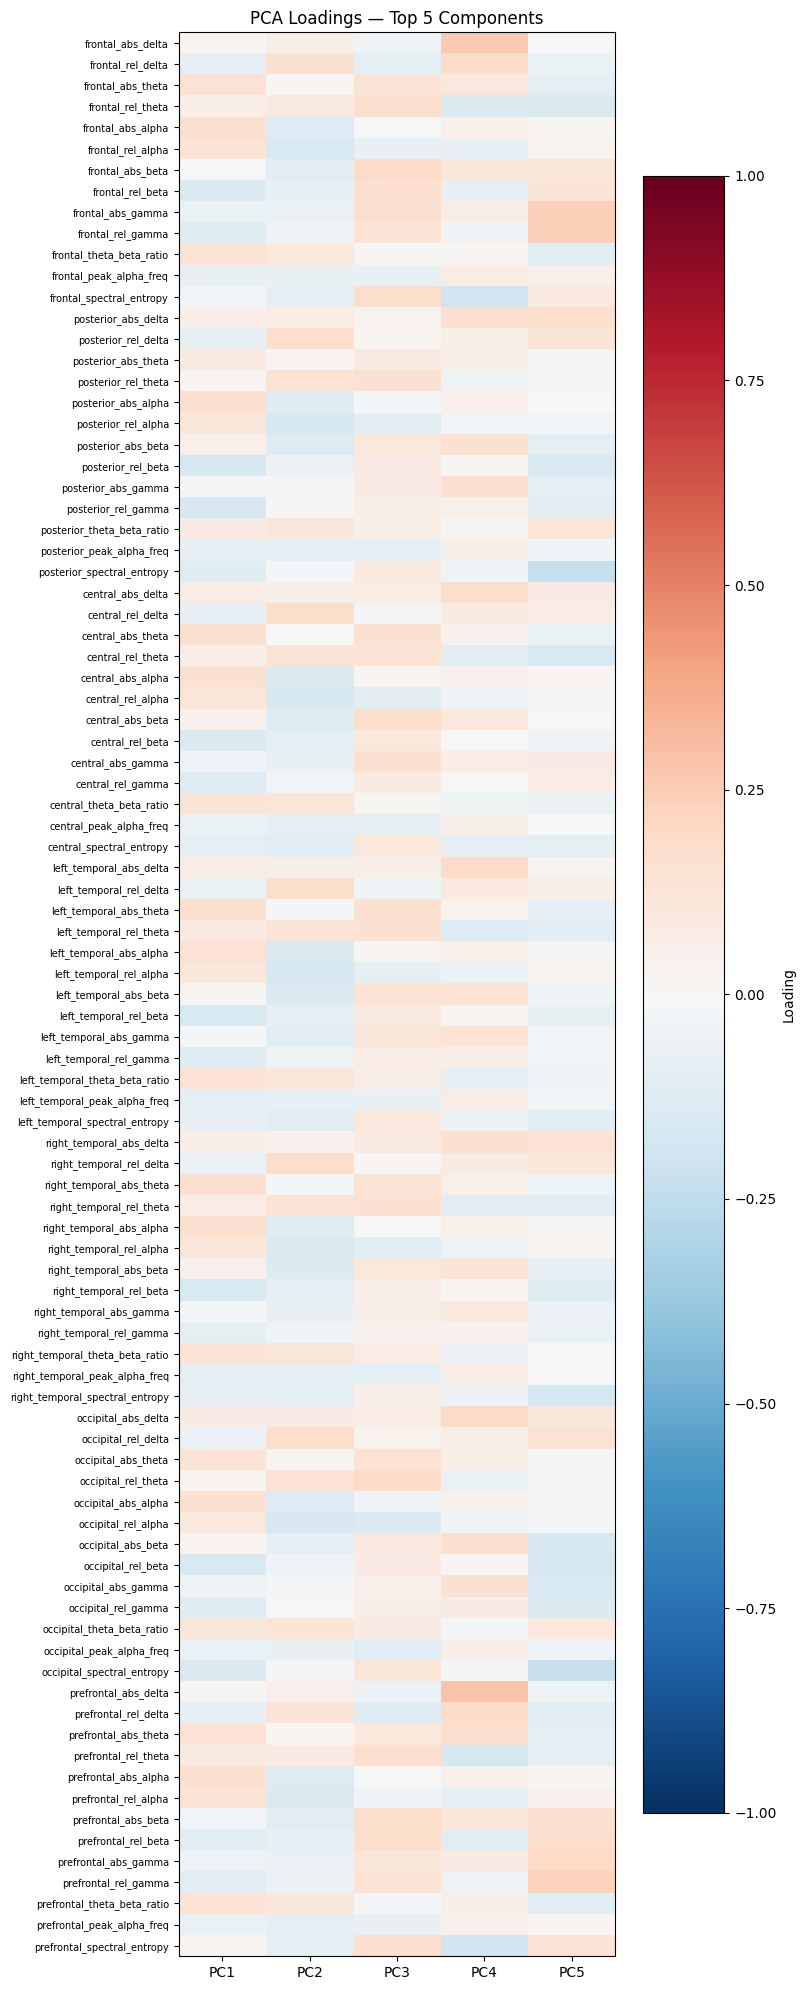

In [11]:
# Loadings heatmap for the top 5 PCs
n_show = 5
eeg_pca_top, _ = run_pca(X_eeg_scaled, n_components=n_show)
loadings = pd.DataFrame(
    eeg_pca_top.components_.T,
    index=feature_cols,
    columns=[f"PC{i+1}" for i in range(n_show)]
)

fig, ax = plt.subplots(figsize=(8, 20))
im = ax.imshow(loadings.values, aspect="auto", cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(n_show))
ax.set_xticklabels(loadings.columns)
ax.set_yticks(range(len(feature_cols)))
ax.set_yticklabels(feature_cols, fontsize=7)
plt.colorbar(im, ax=ax, label="Loading")
ax.set_title("PCA Loadings — Top 5 Components")
plt.tight_layout()
plt.show()